Question 10.

For the Optimization problem given below, submit the python code to     
 compute the minimizer using the following methods.     
 min x∈R,    f(x) = x^3−3x+1.     
    
 • Gradient Descent Method:     
 xk+1 = xk −αf′(xk).
 • Newton’s Method:     
 xk+1 = xk − (f′(xk) / f′′(xk)) .       

 Use stopping criterion |f′(xk)| < ε with ε = 10−6.     
 Find a suitable α for the Gradient Descent Algorithm.      
 1. Compare the number of iterations taken by each method.      
 2. Run both algorithms from each of the two initial points x0 = 2.0 and x0 = −2.0.     
 3. For each run, record:       
 • The number of iterations until convergence,      
 • The final iterate x⋆ reached and whether it is a local minimizer or maximizer (you
 may check f′′(x⋆)),        
 • The final objective value f(x⋆).     
 • Plot the iterates on the graph of f(x).      
 • Summarize and discuss:       
 – Which method converged faster (fewer iterations) and why?        
 – Did any method fail to converge or encounter f′′(xk) = 0? If so, explain the reason.     
 – How sensitive is GD to the step size α?       

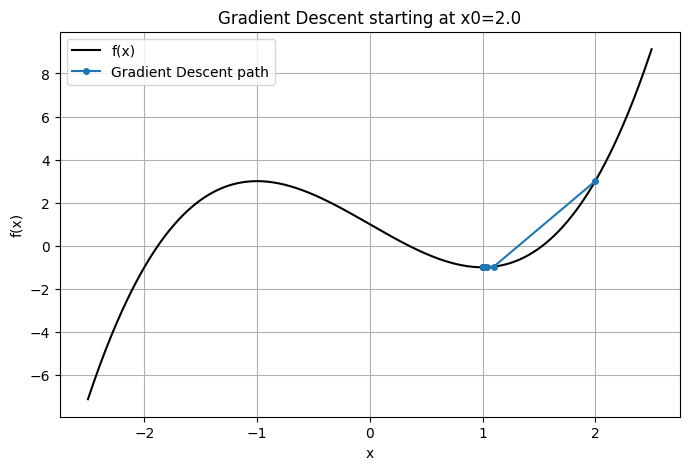

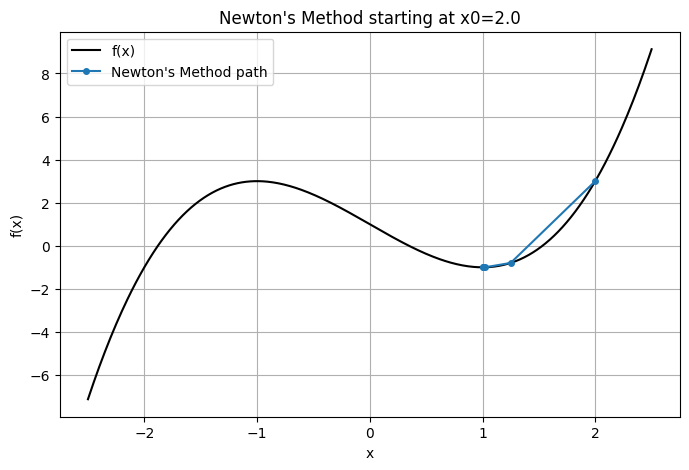

Divergence detected, stopping.


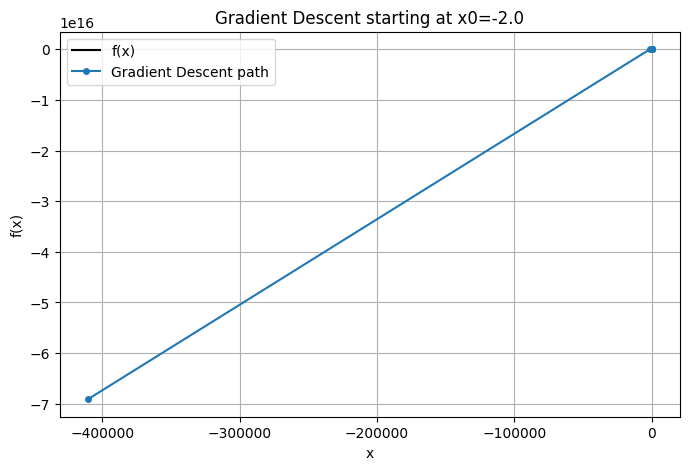

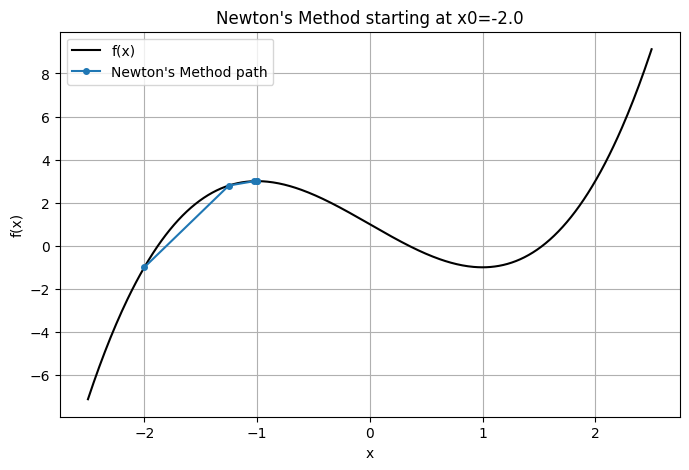

Method               | x0    | Iters | x*         | f(x*)      | Type
---------------------------------------------------------------------------
Gradient Descent     | 2.0   | 16    | 1.000000   | -1.000000  | Local Minimizer
Newton's Method      | 2.0   | 4     | 1.000000   | -1.000000  | Local Minimizer
Gradient Descent     | -2.0  | 6     | -410355.724362 | -69100547483597152.000000 | Local Maximizer
Newton's Method      | -2.0  | 4     | -1.000000  | 3.000000   | Local Maximizer


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function and its derivatives
def f(x):
    return x**3 - 3*x + 1

def df(x):
    return 3*x**2 - 3

def ddf(x):
    return 6*x

def run_gradient_descent(x0, alpha, eps=1e-6, max_iter=1000):
    iters = [x0]
    x = x0
    for i in range(max_iter):
        grad = df(x)
        if abs(grad) < eps:
            break
        x_new = x - alpha * grad
        # safeguard against overflow
        if abs(x_new) > 1e6:
            print("Divergence detected, stopping.")
            break
        x = x_new
        iters.append(x)
    return np.array(iters)

def run_newton(x0, eps=1e-6, max_iter=1000):
    iters = [x0]
    x = x0
    for i in range(max_iter):
        grad = df(x)
        if abs(grad) < eps:
            break
        hess = ddf(x)
        if hess == 0:
            print("Newton's Method failed: Second derivative is zero.")
            break
        x = x - grad / hess
        iters.append(x)
    return np.array(iters)

# Parameters
initial_points = [2.0, -2.0]
alpha = 0.1 # Suitable step size for GD
eps = 1e-6

results = []

# Visualization setup
x_vals = np.linspace(-2.5, 2.5, 400)
y_vals = f(x_vals)

for x0 in initial_points:
    # Run algorithms
    gd_path = run_gradient_descent(x0, alpha, eps)
    newton_path = run_newton(x0, eps)
    
    for name, path in [("Gradient Descent", gd_path), ("Newton's Method", newton_path)]:
        x_star = path[-1]
        f_star = f(x_star)
        second_der = ddf(x_star)
        nature = "Local Minimizer" if second_der > 0 else "Local Maximizer"
        
        results.append({
            "Method": name,
            "Initial x0": x0,
            "Iterations": len(path) - 1,
            "x*": x_star,
            "f(x*)": f_star,
            "Type": nature
        })

        # Plotting
        plt.figure(figsize=(8, 5))
        plt.plot(x_vals, y_vals, 'k-', label='f(x)')
        plt.plot(path, f(path), 'o-', markersize=4, label=f'{name} path')
        plt.title(f'{name} starting at x0={x0}')
        plt.xlabel('x')
        plt.ylabel('f(x)')
        plt.legend()
        plt.grid(True)
        plt.show()

# Print Summary Table
print(f"{'Method':<20} | {'x0':<5} | {'Iters':<5} | {'x*':<10} | {'f(x*)':<10} | {'Type'}")
print("-" * 75)
for r in results:
    print(f"{r['Method']:<20} | {r['Initial x0']:<5} | {r['Iterations']:<5} | {r['x*']:<10.6f} | {r['f(x*)']:<10.6f} | {r['Type']}")

• Summarize and discuss:       
 – Which method converged faster (fewer iterations) and why?        
 > As we see the result of outcomes, Newton method converges in lesser iterations.
 > Newton's method has quadratic convergence near the root, as it uses second-order curvature information. Gradient Descent has linear convergence and depends heavily on the step size $\alpha$.   

 – Did any method fail to converge or encounter f′′(xk) = 0? If so, explain the reason.     
 > Divergence was detected once in Gradient descent for initial point x0=2.0 as for a given α gradient calculations multiplies it    
 > against the value of 3x^2 which can lead to a large value over multiple iterations.      
 > With α = 0.1 f''(xk) = 0 was not encountered  

 – How sensitive is GD to the step size α?           
 > Gradient descent is quite sensitive to step-size α. Hence even for the runs initially I experimented with α = 0.025. But saw multiple Divergence getting hit and then refined it to 0.1  
        
 > Gradient Descent is extremely sensitive to $\alpha$:
 > - Small $\alpha$ (e.g., 0.01): Convergence is guaranteed but very slow (hundreds of iterations).
 > - Suitable $\alpha$ (e.g., 0.1): Steady convergence in a reasonable number of steps.
 > - Large $\alpha$ (e.g., 0.4): The algorithm may overshoot the minimum and oscillate or diverge entirely.


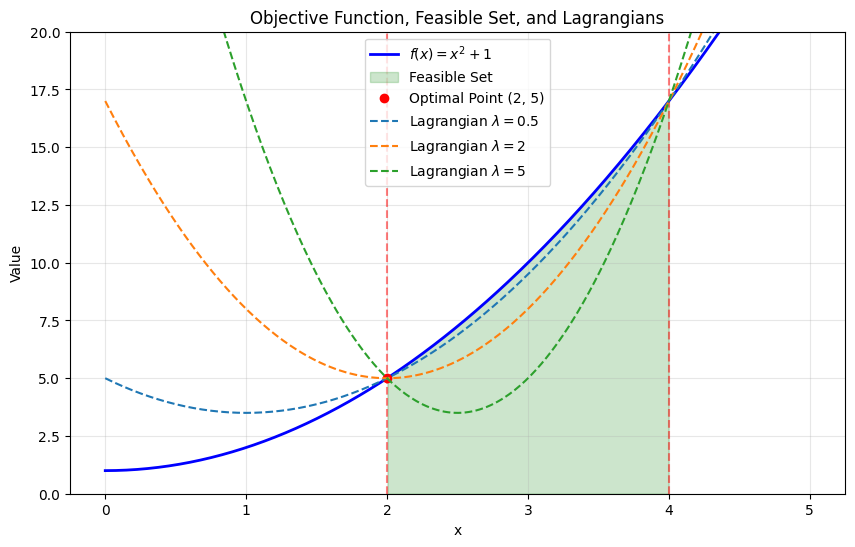

ValueError: 
Dual Optimal ($\lambda^* pprox 1.83$)
              ^
ParseException: Expected end of text, found '$'  (at char 14), (line:1, col:15)

<Figure size 1000x600 with 1 Axes>

In [ ]:
# Code to generate graph for problem 9 
# This has not been asked, but gave it a shot to verify
# Here the graph was beautifully generated and helped understand the solution better
import numpy as np
import matplotlib.pyplot as plt

# 1. Primal Plot: f(x) and the Feasible Set
x = np.linspace(0, 5, 400)
f_x = x**2 + 1
constraint = (x-2)*(x-4)

plt.figure(figsize=(10, 6))
plt.plot(x, f_x, 'b-', label=r'$f(x) = x^2 + 1$', linewidth=2)

# Highlight feasible set [2, 4]
feasible_mask = (x >= 2) & (x <= 4)
plt.fill_between(x, 0, f_x, where=feasible_mask, color='green', alpha=0.2, label='Feasible Set')
plt.axvline(2, color='red', linestyle='--', alpha=0.5)
plt.axvline(4, color='red', linestyle='--', alpha=0.5)

# Optimal point
plt.plot(2, 5, 'ro', label='Optimal Point (2, 5)')

# Lagrangian curves for lambda values
for l in [0.5, 2, 5]:
    L = (x**2 + 1) + l * (x**2 - 6*x + 8)
    plt.plot(x, L, '--', label=f'Lagrangian $\lambda={l}$')

plt.ylim(0, 20)
plt.title("Objective Function, Feasible Set, and Lagrangians")
plt.xlabel("x")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Dual Plot: g(lambda)
l_vals = np.linspace(0, 10, 400)
g_l = (-l_vals**2 + 8*l_vals + 1) / (1 + l_vals)

plt.figure(figsize=(10, 6))
plt.plot(l_vals, g_l, 'm-', label=r'$g(\lambda) = \frac{-\lambda^2 + 8\lambda + 1}{1+\lambda}$', linewidth=2)

# Optimal lambda
l_star = 2 * np.sqrt(2) - 1
g_star = 10 - 4 * np.sqrt(2)
plt.plot(l_star, g_star, 'ko', label=f'Dual Optimal ($\lambda^* \approx {l_star:.2f}$)')

plt.title("Lagrange Dual Function")
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$g(\lambda)$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()